In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# 1. Generate credit data (1000 financial records)
np.random.seed(42)
n_samples = 1000

data = {
    'Age': np.random.randint(21, 70, size=n_samples),
    'Annual_Income': np.random.normal(55000, 15000, size=n_samples).astype(float),
    'Credit_Score': np.random.randint(300, 850, size=n_samples),
    'Loan_Amount': np.random.normal(15000, 8000, size=n_samples).clip(1000).astype(float),
    'Total_Accounts': np.random.randint(1, 15, size=n_samples),
    'Derogatory_Marks': np.random.choice([0, 1, 2, 3], size=n_samples, p=[0.8, 0.12, 0.05, 0.03]),
    'Payment_History_Excellent': np.random.choice([0, 1], size=n_samples, p=[0.3, 0.7])
}

df = pd.DataFrame(data)

# Create target variable (Creditworthy: 1 = Good credit, 0 = Default/Bad credit) using financial logic
debt_to_income = df['Loan_Amount'] / df['Annual_Income']
score_component = (df['Credit_Score'] - 300) / 550
history_component = df['Payment_History_Excellent'] * 0.4 - df['Derogatory_Marks'] * 0.2
prob = 1 / (1 + np.exp(-(score_component - debt_to_income + history_component - 0.2)))
df['Creditworthy'] = (prob > 0.45).astype(int)

# Introduce missing values in Annual_Income for cleaning practice
df.loc[df.sample(frac=0.02, random_state=42).index, 'Annual_Income'] = np.nan

print("--- 1. Initial Credit Data Preview ---")
print(df.head())

print("\n--- 2. Missing Values Check Before Cleaning ---")
print(df.isnull().sum())

# Data Cleaning: Fill missing values in Annual_Income with its median
df['Annual_Income'] = df['Annual_Income'].fillna(df['Annual_Income'].median())

print("\n--- 3. Missing Values Check After Cleaning ---")
print(df.isnull().sum())


--- 1. Initial Credit Data Preview ---
   Age  Annual_Income  Credit_Score   Loan_Amount  Total_Accounts  \
0   59   57609.494938           649  16066.057871              12   
1   49   68618.079209           482   1006.239656               4   
2   35   54868.141655           412  21202.235170               5   
3   63   61771.167980           482   3837.330190              13   
4   28   67237.774307           780   1000.000000               6   

   Derogatory_Marks  Payment_History_Excellent  Creditworthy  
0                 1                          0             1  
1                 0                          1             1  
2                 1                          1             1  
3                 0                          1             1  
4                 0                          0             1  

--- 2. Missing Values Check Before Cleaning ---
Age                           0
Annual_Income                20
Credit_Score                  0
Loan_Amount            

In [2]:
# 1. Feature Engineering: Create meaningful financial ratios
# Calculate Debt-to-Income (DTI) ratio
df['Debt_to_Income_Ratio'] = df['Loan_Amount'] / df['Annual_Income']

# Calculate average income distributed per open bank/credit account
df['Income_per_Account'] = df['Annual_Income'] / df['Total_Accounts']

print("--- 4. Feature Engineering Preview ---")
print(df[['Annual_Income', 'Loan_Amount', 'Debt_to_Income_Ratio', 'Income_per_Account']].head())

# 2. Split data into Features (X) and Target (y)
X = df.drop(columns=['Creditworthy'])
y = df['Creditworthy']

# 3. Split the dataset into Training set (80%) and Testing set (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("\n--- 5. Dataset Splitting Complete ---")
print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")


--- 4. Feature Engineering Preview ---
   Annual_Income   Loan_Amount  Debt_to_Income_Ratio  Income_per_Account
0   57609.494938  16066.057871              0.278879         4800.791245
1   68618.079209   1006.239656              0.014664        17154.519802
2   54868.141655  21202.235170              0.386422        10973.628331
3   61771.167980   3837.330190              0.062122         4751.628306
4   67237.774307   1000.000000              0.014873        11206.295718

--- 5. Dataset Splitting Complete ---
Training features shape: (800, 9)
Testing features shape: (200, 9)


In [3]:
from sklearn.ensemble import RandomForestClassifier

# 1. Initialize the Random Forest Model
# n_estimators=100 means we are building a forest of 100 decision trees
# random_state=42 ensures that the results are reproducible every time you run the code
model = RandomForestClassifier(n_estimators=100, random_state=42)

print("--- 6. Training the Credit Scoring Model ---")
# 2. Train the model using the 80% training data (Features and Target)
model.fit(X_train, y_train)
print("Model training completed successfully!")

# 3. Make predictions on the 20% testing data (Unseen Data)
y_pred = model.predict(X_test)

# 4. Predict probabilities (Useful for checking credit risk levels)
y_pred_proba = model.predict_proba(X_test)[:, 1]
print("Predictions on testing data generated successfully!")


--- 6. Training the Credit Scoring Model ---
Model training completed successfully!
Predictions on testing data generated successfully!


--- 7. Credit Scoring Model Evaluation Metrics ---
Model General Accuracy: 97.00%

Classification Report:
                    precision    recall  f1-score   support

Default/Bad Credit       0.91      0.91      0.91        33
       Good Credit       0.98      0.98      0.98       167

          accuracy                           0.97       200
         macro avg       0.95      0.95      0.95       200
      weighted avg       0.97      0.97      0.97       200

ROC-AUC Score: 0.9833



C:\Users\User\AppData\Local\Temp\ipykernel_18412\2308981295.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=X.columns[indices], palette="viridis")


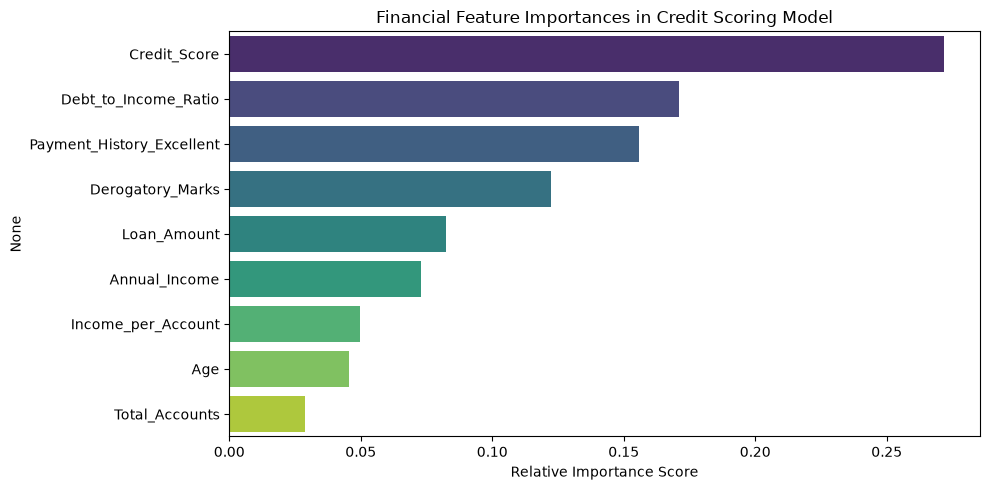

In [4]:
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix

print("--- 7. Credit Scoring Model Evaluation Metrics ---")

# Calculate and print general Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model General Accuracy: {accuracy * 100:.2f}%\n")

# Generate Classification Report (Precision, Recall, F1-Score)
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Default/Bad Credit', 'Good Credit']))

# Calculate and print ROC-AUC Score
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC-AUC Score: {roc_auc:.4f}\n")

# 6. Plotting Feature Importance to see what matters most in Credit Scoring
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 5))
plt.title("Financial Feature Importances in Credit Scoring Model")
sns.barplot(x=importances[indices], y=X.columns[indices], palette="viridis")
plt.xlabel("Relative Importance Score")
plt.tight_layout()
plt.show()
